Updated version with improved analysis (2026)

 🩺 Diabetes Prediction Project using Machine Learning (SVM)

## Introduction
Diabetes is one of the most common chronic diseases worldwide, affecting millions of people and leading to serious health complications if not detected early.

In this project, I used machine learning techniques to predict whether a patient is likely to have diabetes based on medical features such as glucose level, BMI, age, and other health indicators.

## Objective
The goal of this project is to build a predictive model that can help in early detection of diabetes and support healthcare decision-making.

## Dataset
This dataset contains medical records such as glucose level, BMI, age, and other health indicators.and one target variable (Outcome), where:
- 0 → No Diabetes  
- 1 → Diabetes  

## Tools & Technologies
- Python
- Pandas
- Scikit-learn
- Matplotlib / Seaborn
- 
## Approach
- Data Exploration
- Data Cleaning
- Feature Selection
- Model Training (SVM)
- Model Evaluation

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Load Data

In [2]:
df_data= pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')

Data Understanding 

In [3]:
#print first 5 rows of the data
df_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#print last 5 rows of the data
df_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
#number of rows and columns
df_data.shape

(768, 9)

In [6]:
#getting some info about the data
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
#cheking for missing values
df_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df_data['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

0---Negative diabetes

1---Positive diabetes

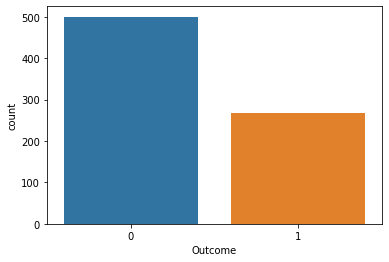

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df_data)
plt.show()

Splitting the features and outcome

In [11]:
X= df_data.drop(columns='Outcome',axis=1)
Y= df_data['Outcome']

In [12]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [13]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [14]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [15]:
print(X.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


Model training

In [16]:
from sklearn import svm

In [17]:
classifier= svm.SVC(kernel="linear")

In [18]:
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

Evaluation

In [19]:
X_train_prediction = classifier.predict(X_train)
train_accuracy =accuracy_score(Y_train,X_train_prediction)
print("Accuracy score for train data:-",train_accuracy)

Accuracy score for train data:- 0.7719869706840391


In [20]:
X_test_prediction = classifier.predict(X_test)
test_accuracy =accuracy_score(Y_test,X_test_prediction)
print("Accuracy score for train data:-",test_accuracy)

Accuracy score for train data:- 0.7532467532467533


Prediction Example:
This section demonstrates how the trained model can predict
whether a patient is diabetic based on input features.

Prediction Example

In [21]:

# Example: Non-diabetic patient
#input_data = (2, 90, 60, 20, 85, 25.0, 0.2, 22)
#Example: diabetic patient
input_data = (0, 137, 40, 35, 168, 43.1, 2.288, 33)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)


prediction = classifier.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')


[1]
The person is diabetic


This model can help healthcare providers identify high-risk patients early,
allowing for better preventive care and reduced complications.